In [4]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, r2_score

In [5]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.drop(["EmployeeNumber", "Over18", "StandardHours"], axis=1, inplace=True)

In [7]:
df.shape

(1470, 32)

In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [10]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [11]:
df.isnull().sum().sum()

0

In [12]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [13]:
X_class = df.drop("Attrition", axis=1)
y_class = df["Attrition"]

In [14]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

In [15]:
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_c, y_train_c)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred_c = clf.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print(classification_report(y_test_c, y_pred_c))

Accuracy: 0.8775510204081632
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



In [17]:
y_prob = clf.predict_proba(X_test_c)[:, 1]
risk_score = y_prob * 100

In [18]:
def risk_category(score):
    if score < 30:
        return "Low Risk"
    elif score < 70:
        return "Medium Risk"
    else:
        return "High Risk"

risk_labels = [risk_category(s) for s in risk_score]

In [19]:
df_risk = pd.DataFrame({
    "Attrition_Probability": y_prob,
    "Risk_Score (%)": risk_score,
    "Risk_Category": risk_labels
})

df_risk.head()

,Attrition_Probability,Risk_Score (%),Risk_Category
0,0.175,17.5,Low Risk
1,0.050,5.0,Low Risk
2,0.460,46.0,Medium Risk
3,0.090,9.0,Low Risk
4,0.045,4.5,Low Risk


In [20]:
X_reg = df.drop("PercentSalaryHike", axis=1)
y_reg = df["PercentSalaryHike"]

In [21]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [22]:
reg = RandomForestRegressor(n_estimators=200, random_state=42)
reg.fit(X_train_r, y_train_r)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
y_pred_r = reg.predict(X_test_r)

print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("R2 Score:", r2_score(y_test_r, y_pred_r))

MAE: 1.9140816326530612
R2 Score: 0.5912382145450591


In [25]:
explainer = shap.Explainer(clf, X_train_c)
shap_values = explainer(X_test_c)

 98%|===================| 576/588 [00:30<00:00]        

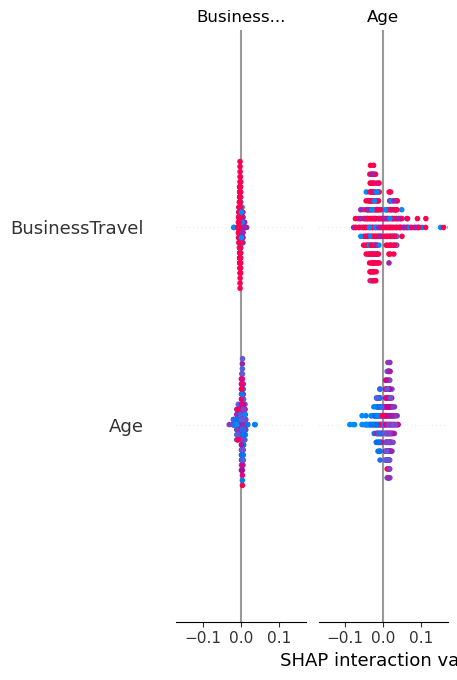

In [26]:
shap.summary_plot(shap_values)

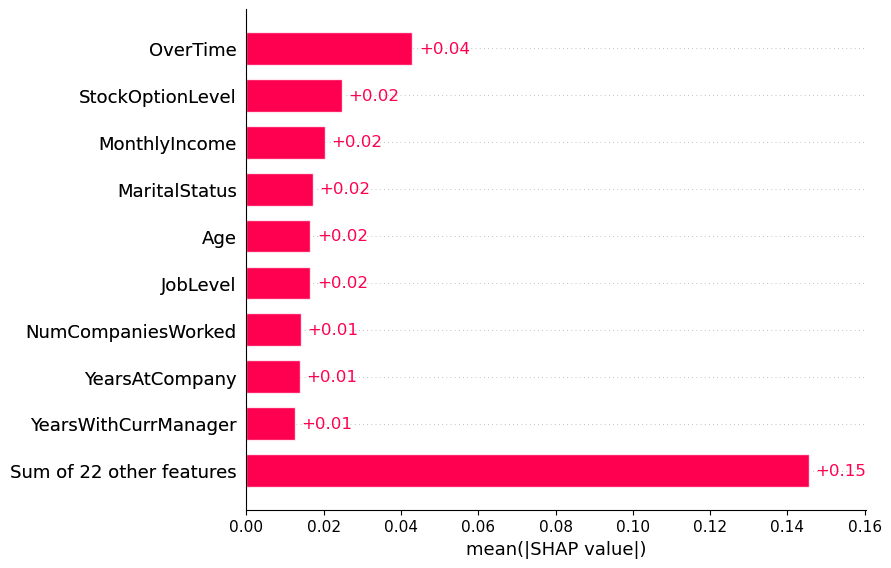

In [28]:
# Select class 1 (Attrition = Yes)
shap.plots.bar(shap_values[:, :, 1])

 97%|=================== | 572/588 [00:27<00:00]       

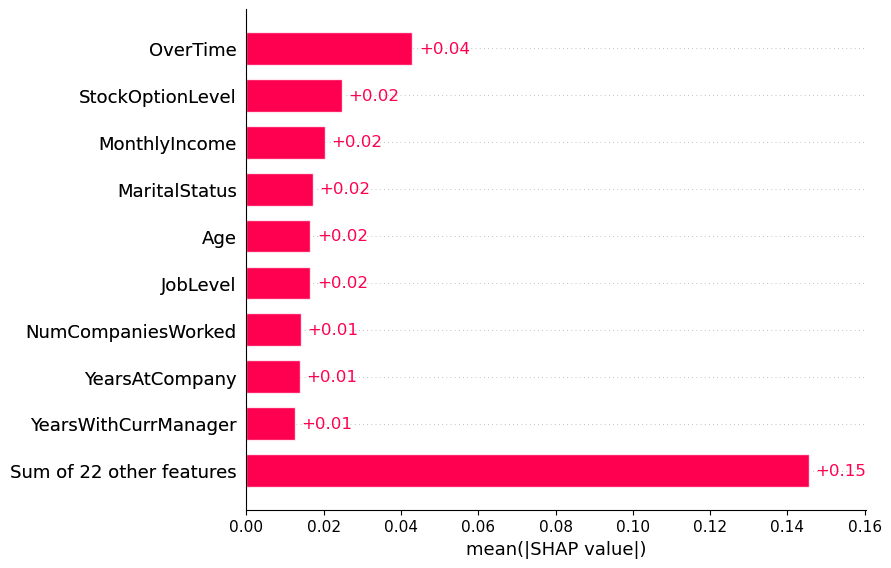

In [29]:
explainer = shap.Explainer(clf, X_train_c)
shap_values = explainer(X_test_c)

# Global Importance
shap.plots.bar(shap_values[:, :, 1])

# Local Explanation (First Employee)
shap.plots.force(
    shap_values.base_values[0][1],
    shap_values.values[0][:, 1],
    X_test_c.iloc[0]
)

In [30]:
# Select class 1 (Attrition = Yes)
class_1_values = shap_values.values[:, :, 1]

# Take mean absolute importance
mean_importance = np.abs(class_1_values).mean(axis=0)

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_test_c.columns,
    'Importance': mean_importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

                 Feature  Importance
19              OverTime    0.042918
23      StockOptionLevel    0.024640
16         MonthlyIncome    0.020291
15         MaritalStatus    0.017234
0                    Age    0.016527
12              JobLevel    0.016524
18    NumCompaniesWorked    0.014011
27        YearsAtCompany    0.013870
30  YearsWithCurrManager    0.012470
4       DistanceFromHome    0.012237


In [31]:
employee_index = 0

top3_local = (
    pd.DataFrame({
        "Feature": X_test_c.columns,
        "SHAP Value": shap_values.values[employee_index][:, 1]
    })
    .assign(abs_val=lambda x: x["SHAP Value"].abs())
    .sort_values("abs_val", ascending=False)
    .drop(columns="abs_val")
    .head(3)
)

print(top3_local)

             Feature  SHAP Value
14   JobSatisfaction    0.036597
23  StockOptionLevel    0.034698
15     MaritalStatus    0.023969
